In [120]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [121]:
weight = 0.7
bias = 0.3



start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [122]:
train_split = 0.8 * len(X)
X_train, Y_train = X[:int(train_split)], y[:int(train_split)]
X_test, Y_test = X[int(train_split):], y[int(train_split):]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

In [123]:
X_train, Y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [124]:
def plot_predictions(train_data=X_train,
                    train_labels=Y_train,
                    test_data=X_test,
                    test_labels=Y_test,
                    predictions=None):
  plt.figure(figsize=(10, 7))

  #Plot training data in black
  plt.scatter(train_data, train_labels, c="black", s=8, label="Training data");

  #Plot test data in red
  plt.scatter(test_data, test_labels, c="red", s=8, label="Testing data");

  #Are there Predictions?
  if predictions is not None:
    plt.scatter(test_data, predictions, c="green", s=8, label="Predictions");

  plt.legend(prop={"size": 15});

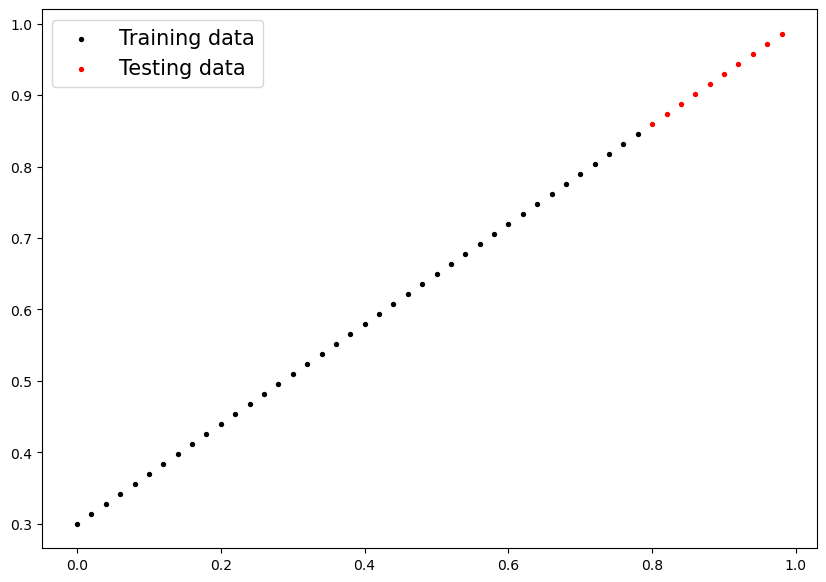

In [125]:
plot_predictions();

In [ ]:
#Create linear regression model class
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  #Forward method to define the computations in model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [127]:
torch.manual_seed(42)

#Create an instance of the model
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [128]:
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [129]:
Y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

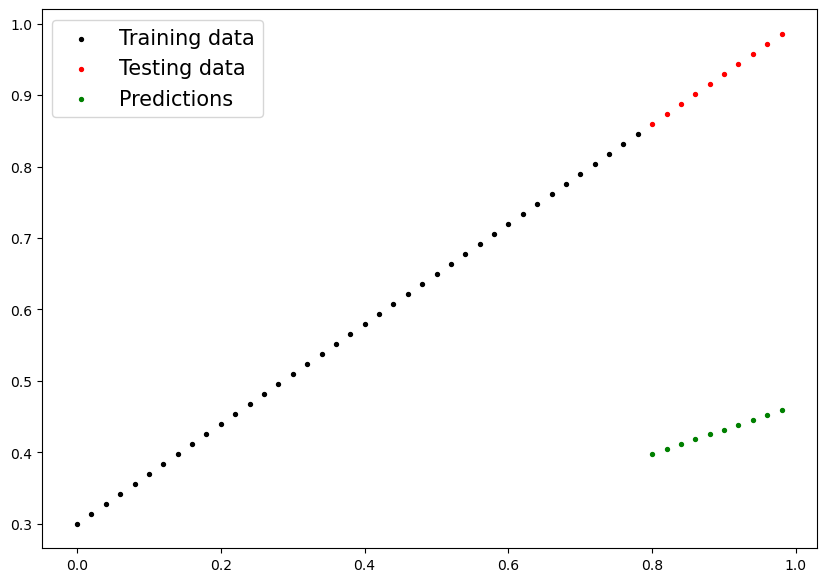

In [130]:
plot_predictions(predictions=y_preds)

In [131]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [132]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [133]:
loss_fn = nn.L1Loss()

In [134]:
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

### Building a traing loop in PyTorch

In [313]:
torch.manual_seed(42)
epochs = 200
epoch_count = []
loss_values_list = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train()

  y_pred = model_0(X_train.cpu())
  loss = loss_fn(y_pred, Y_train)
  # print(f"Loss: {loss}")
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test.cpu())
    test_loss = loss_fn(test_pred, Y_test)
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values_list.append(loss)
    test_loss_values.append(test_loss)

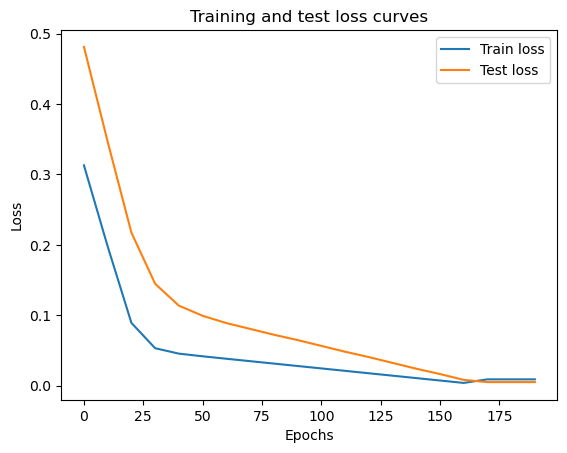

In [137]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values_list).detach().numpy()), label="Train loss")
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).detach().numpy()), label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

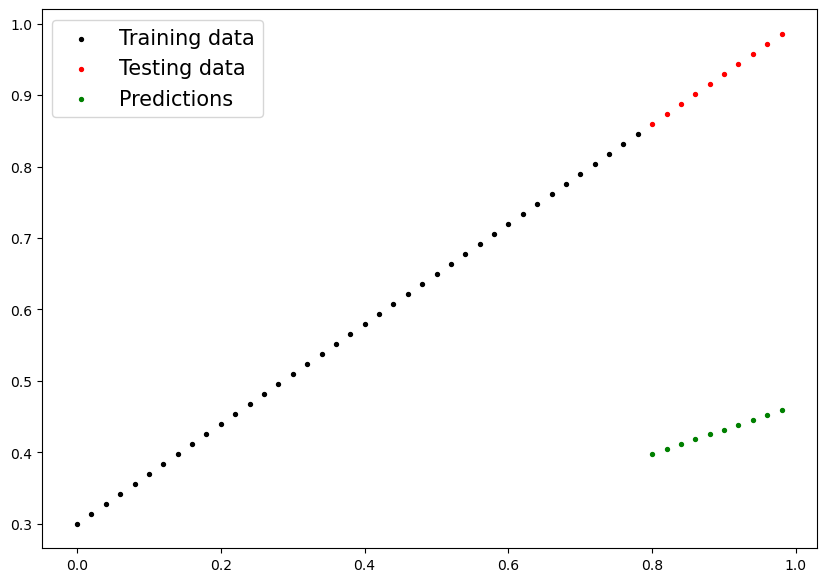

In [140]:
plot_predictions(predictions=y_preds)

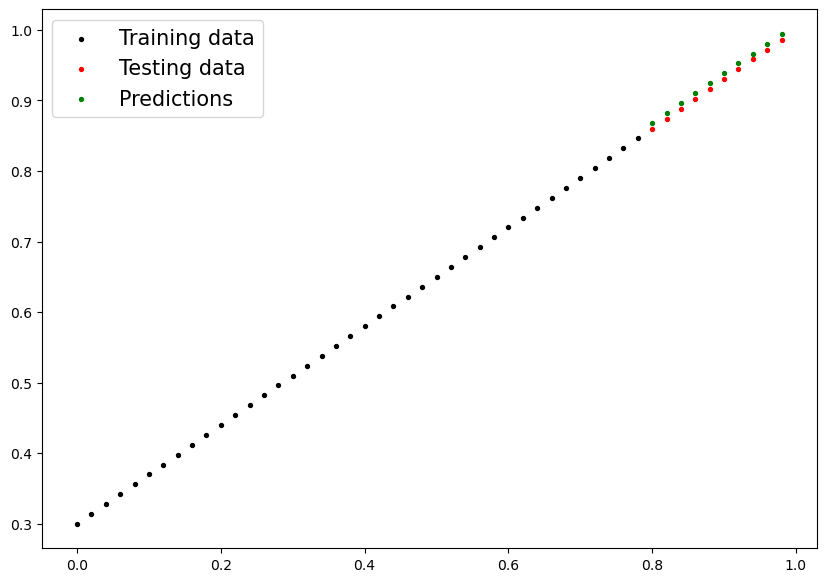

In [141]:
plot_predictions(predictions=y_pred_new)

## Saving a Model in PyTorch

In [142]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [143]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "01_pytorch_workflow.model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow.model_0.pth


## Loading a Pytorch mode

In [144]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [145]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [146]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [147]:
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [148]:
model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [149]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [259]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0'

In [260]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using Device: {device}")

Using Device: mps


## Data

In [261]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [262]:
# The 80% / 20% split for training and test
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

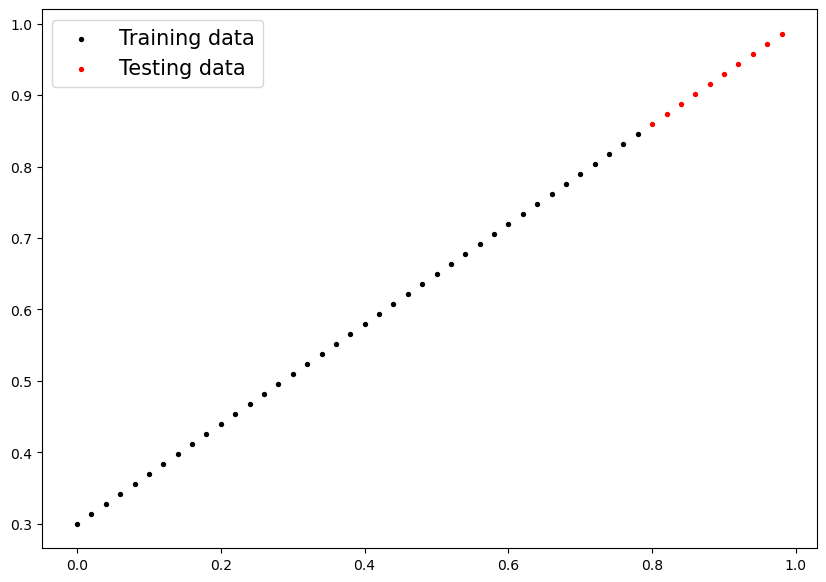

In [263]:
plot_predictions(X_train.detach().numpy(), y_train, X_test, y_test)

## Building a Pytorch linear model

In [264]:
class MyPrimaryModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(X)

torch.manual_seed(42)
first_model = MyPrimaryModel()
first_model, first_model.state_dict()

(MyPrimaryModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [265]:
next(first_model.parameters()).device

device(type='cpu')

In [266]:
first_model.to(device)
next(first_model.parameters()).device

device(type='mps', index=0)

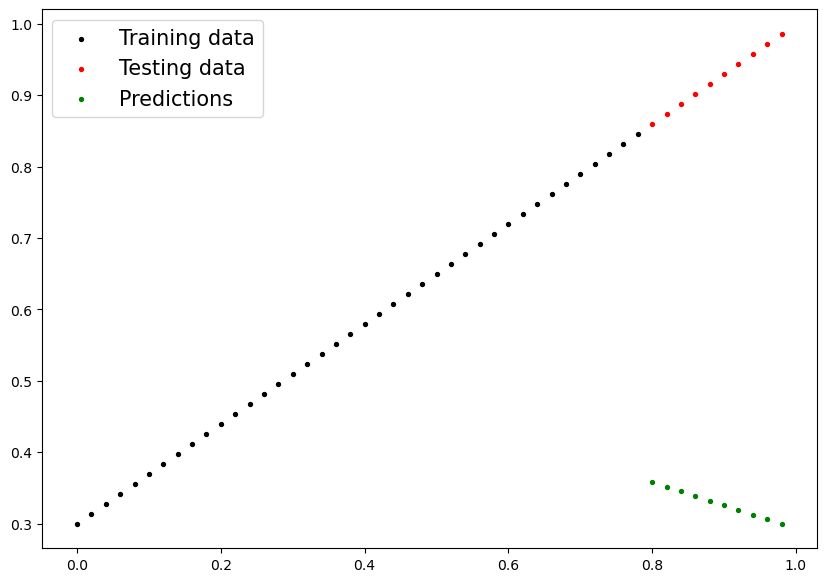

In [289]:
my_model = MyPrimaryModel()
with torch.inference_mode():
  plot_predictions(predictions=my_model(X_test.cpu()))

### Training Model

Epoch: 0 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 10 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 20 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 30 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 40 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 50 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 60 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 70 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 80 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 90 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 100 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 110 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 120 | Loss: 0.010256480425596237 | Test loss: 0.0003308236482553184
Epoch: 130 | Loss: 0.010256480425596

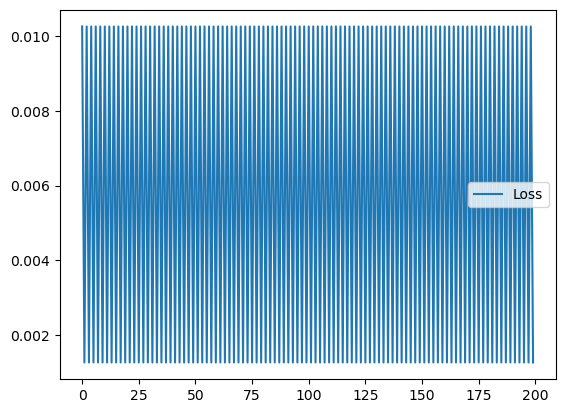

In [310]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=first_model.parameters(), lr=0.01)

# Training loop

torch.manual_seed(42)

epochs = 200
epoch_count = []
loss_values_list = []
test_loss_values = []

#Put the data on target device

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
    first_model.train()

    y_pred = first_model(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # Testing
    first_model.eval()
    with torch.inference_mode():
        test_pred = first_model(X_test)

        test_loss = loss_fn(test_pred, y_test)
        epoch_count.append(epoch)
        loss_values_list.append(loss.cpu())
        test_loss_values.append(test_loss)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

plt.plot(range(0, len(loss_values_list)), loss_values_list, label="Loss")
plt.legend()

In [300]:
first_model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='mps:0')),
             ('linear_layer.bias', tensor([0.3025], device='mps:0'))])

In [296]:
first_model.eval()

with torch.inference_mode():
    y_after_train = first_model(X_test)

y_after_train

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='mps:0')

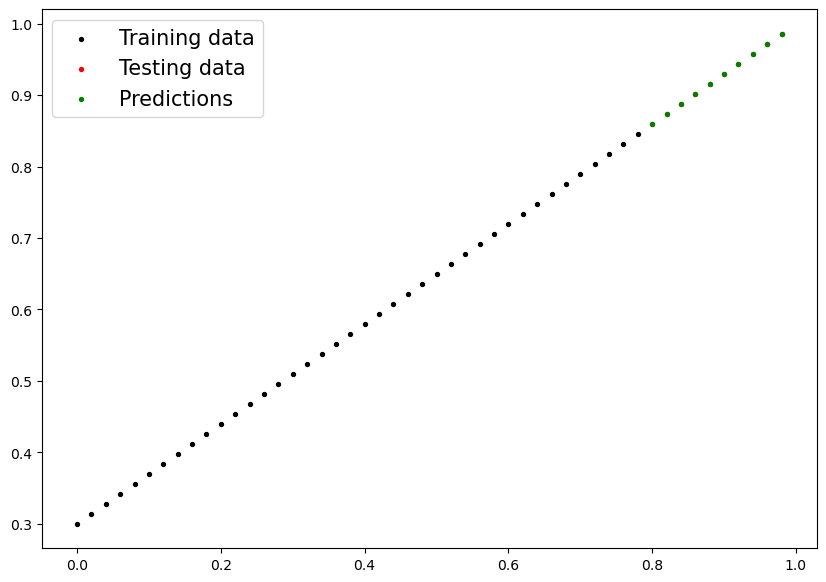

In [304]:
plot_predictions(predictions=y_after_train.cpu())

## Let's test

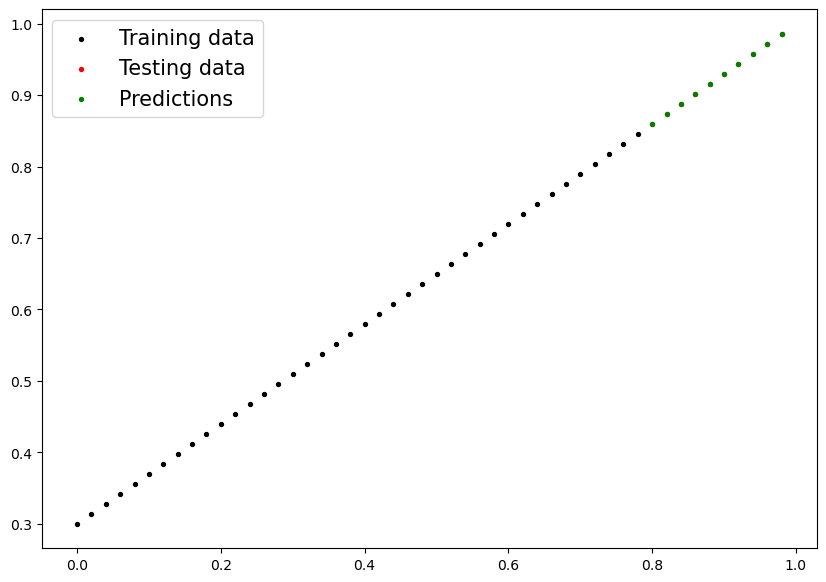

In [298]:
first_model.eval()

y_pred_after_train = first_model(X_test)

with torch.inference_mode():
    plot_predictions(predictions=y_pred_after_train.cpu())